In [1]:
import sys
import metpy.calc as mpcalc
import metpy.units as units
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import tqdm
from dask.distributed import Client
import pandas as pd

sys.path.append('/g/data/ng72/ab4502/hot-cloudy/modules/')
from fronts import *

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38985,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39107,Total threads: 2
Dashboard: /proxy/34829/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:34801,


In [3]:
def barra_front(t):

    domain_id = "AUS-11"
    freq = "1hr"
    lat_slice = slice(-45,-10)
    lon_slice = slice(110,160)
    chunks = {}
    smooth = False
    sigma=None

    p = 700

    front_thresh = 8*(units.units.K / units.units.km)
    
    interp_lon = np.arange(110,160.75,0.75)
    interp_lat = np.arange(-45,-9.25,0.75)    

    psl = load_barra_variable("psl",t,t,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    ta = load_barra_variable("ta"+str(p),t,t,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    q = load_barra_variable("hus"+str(p),t,t,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    u = load_barra_variable("ua"+str(p),t,t,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    v = load_barra_variable("va"+str(p),t,t,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    w = load_barra_variable("wa"+str(p),t,t,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    cape = load_barra_variable("CAPE",t,t,domain_id,freq,lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    qfluxu = load_barra_variable("qfluxu",t + dt.timedelta(hours=1.5),t + dt.timedelta(hours=1.5),domain_id,"3hr",lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    qfluxv = load_barra_variable("qfluxv",t + dt.timedelta(hours=1.5),t + dt.timedelta(hours=1.5),domain_id,"3hr",lat_slice,lon_slice,chunks=chunks,smooth=smooth,sigma=sigma)
    wind = xr.Dataset({"u":u,"v":v,"w":w}).squeeze()
    qflux = np.sqrt(qfluxu**2 + qfluxv**2)

    psl_interp = psl.interp(lat=interp_lat,lon=interp_lon,method="linear")
    ta_interp = ta.interp(lat=interp_lat,lon=interp_lon,method="linear")
    q_interp = q.interp(lat=interp_lat,lon=interp_lon,method="linear")   
    wind_interp = wind.interp(lat=interp_lat,lon=interp_lon,method="linear")   
    qflux_interp = qflux.interp(lat=interp_lat,lon=interp_lon,method="linear")   

    dp_interp = mpcalc.dewpoint_from_specific_humidity(p * units.units.hectopascal, ta_interp, q_interp)
    thetae_interp = mpcalc.equivalent_potential_temperature(p * units.units.hectopascal, ta_interp, dp_interp)    
    dx, dy = mpcalc.lat_lon_grid_deltas(ta_interp.lon,ta_interp.lat)
    ddy_thetae = mpcalc.first_derivative( thetae_interp.squeeze(), delta=dy, axis=0)
    ddx_thetae = mpcalc.first_derivative( thetae_interp.squeeze(), delta=dx, axis=1)
    mag_thetae = np.sqrt( ddx_thetae**2 + ddy_thetae**2).to("K/km") * 100
    mag_thetae_da = xr.DataArray(mag_thetae,dims=["lat","lon"],coords={"lat":ta_interp.lat,"lon":ta_interp.lon})    

    return mag_thetae_da>front_thresh, q_interp, wind_interp, psl_interp, qflux_interp, cape

In [4]:
dates = pd.read_csv("/g/data/ng72/ab4502/hot-cloudy/data/event_dates_csi0p5_tmax90_carl_andrew_sanaa.csv",index_col=0)
dates["time"] = pd.to_datetime(dates["time"])
dates = dates[(dates.sanaa==1) & (dates.region=="GMEL")]
cases = dates.time

In [5]:
fronts = []
qs = []
winds = []
psls = []
qfluxs = []
capes = []

for time in tqdm.tqdm(cases):
    front, q, wind, psl, qflux, cape = barra_front(time.replace(hour=6))
    fronts.append(front)
    qs.append(q.squeeze())
    winds.append(wind)
    qfluxs.append(qflux.squeeze())
    psls.append(psl.squeeze())
    capes.append(cape.squeeze())

100%|██████████| 47/47 [05:31<00:00,  7.06s/it]


In [6]:
qmean = xr.concat(qs,dim="cases").mean("cases").persist()
wind_mean = xr.concat(winds,dim="cases").mean("cases").persist()
fronts_mean = xr.concat(fronts,dim="cases").mean("cases").persist()
psl_mean = xr.concat(psls,dim="cases").mean("cases").persist()
qflux_mean = xr.concat(qfluxs,dim="cases").mean("cases").persist()
cape_mean = xr.concat(capes,dim="cases").mean("cases").persist()

In [7]:
null_dates = pd.read_csv("/g/data/ng72/ab4502/hot-cloudy/data/null_event_dates_csi0p5_thourly90_nhours7.csv",index_col=0)
null_dates["time"] = pd.to_datetime(null_dates["time"])
null_dates = null_dates[null_dates.region=="GMEL"]
null_cases = null_dates.time


In [8]:
null_fronts = []
null_qs = []
null_winds = []
null_psls = []
null_qfluxs = []
null_capes = []

for time in tqdm.tqdm(null_cases):
    front, q, wind, psl, qflux, cape = barra_front(time.replace(hour=6))
    null_fronts.append(front)
    null_qs.append(q.squeeze())
    null_winds.append(wind)
    null_psls.append(psl.squeeze())
    null_qfluxs.append(qflux.squeeze())
    null_capes.append(cape.squeeze())

100%|██████████| 38/38 [07:06<00:00, 11.23s/it]  


In [9]:
null_qmean = xr.concat(null_qs,dim="cases").mean("cases").persist()
null_wind_mean = xr.concat(null_winds,dim="cases").mean("cases").persist()
null_fronts_mean = xr.concat(null_fronts,dim="cases").mean("cases").persist()
null_psl_mean = xr.concat(null_psls,dim="cases").mean("cases").persist()
null_qflux_mean = xr.concat(null_qfluxs,dim="cases").mean("cases").persist()
null_cape_mean = xr.concat(null_capes,dim="cases").mean("cases").persist()

Text(0.5, 1.0, 'Mean CAPE (null events)')

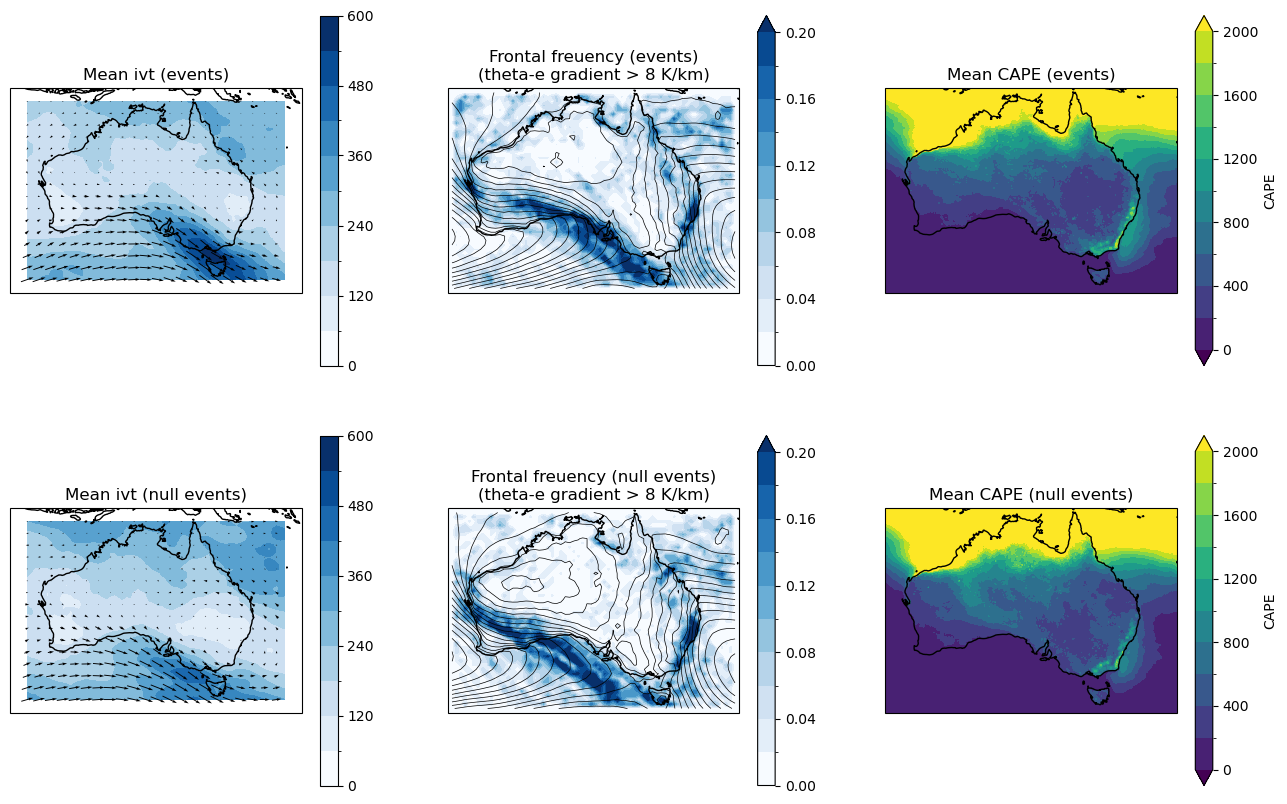

In [10]:
plt.figure(figsize=[16,10])

c=3

ax=plt.subplot(2,3,1,projection=ccrs.PlateCarree())
#xr.plot.contourf(qmean,cmap="Blues",levels=np.linspace(0,0.01,11))
xr.plot.contourf(qflux_mean,cmap="Blues",levels=np.linspace(0,600,11))
wind_mean.coarsen({"lon":c,"lat":c},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v",scale=400)
ax.coastlines()
plt.title("Mean ivt (events)")

ax=plt.subplot(2,3,2,projection=ccrs.PlateCarree())
xr.plot.contourf(fronts_mean,cmap="Blues",robust=True,levels=np.linspace(0,0.2,11))
xr.plot.contour(psl_mean,levels=np.linspace(100000,102000,21),colors="k",linewidths=0.5)
ax.coastlines()
plt.title("Frontal freuency (events)\n(theta-e gradient > 8 K/km)")

ax=plt.subplot(2,3,3,projection=ccrs.PlateCarree())
#xr.plot.contourf(wind_mean.w,vmax=0.05,vmin=-0.05,cmap="RdBu",levels=10,extend="both")
xr.plot.contourf(cape_mean,levels=np.linspace(0,2000,11),extend="both")
ax.coastlines()
plt.title("Mean CAPE (events)")





ax=plt.subplot(2,3,4,projection=ccrs.PlateCarree())
#xr.plot.contourf(qmean,cmap="Blues",levels=np.linspace(0,0.01,11))
xr.plot.contourf(null_qflux_mean,cmap="Blues",levels=np.linspace(0,600,11))
null_wind_mean.coarsen({"lon":c,"lat":c},boundary="trim").mean().plot.quiver(x="lon",y="lat",u="u",v="v",scale=400)
ax.coastlines()
plt.title("Mean ivt (null events)")

ax=plt.subplot(2,3,5,projection=ccrs.PlateCarree())
xr.plot.contourf(null_fronts_mean,cmap="Blues",robust=True,levels=np.linspace(0,0.2,11))
xr.plot.contour(null_psl_mean,levels=np.linspace(100000,102000,21),colors="k",linewidths=0.5)
ax.coastlines()
plt.title("Frontal freuency (null events)\n(theta-e gradient > 8 K/km)")

ax=plt.subplot(2,3,6,projection=ccrs.PlateCarree())
#xr.plot.contourf(null_wind_mean.w,vmax=0.05,vmin=-0.05,cmap="RdBu",levels=10,extend="both")
xr.plot.contourf(null_cape_mean,levels=np.linspace(0,2000,11),extend="both")
ax.coastlines()
plt.title("Mean CAPE (null events)")


In [11]:
xr.merge([
    qmean,
    wind_mean,
    xr.Dataset({"fronts":fronts_mean}),
    psl_mean,
    xr.Dataset({"qflux":qflux_mean}),
    cape_mean.rename({"lat":"lat2","lon":"lon2"})]).to_netcdf("/g/data/gb02/ab4502/hot_cloudy/melbourne_event_compoisite.nc")

xr.merge([
    null_qmean,
    null_wind_mean,
    xr.Dataset({"fronts":null_fronts_mean}),
    null_psl_mean,
    xr.Dataset({"qflux":null_qflux_mean}),
    null_cape_mean.rename({"lat":"lat2","lon":"lon2"})]).to_netcdf("/g/data/gb02/ab4502/hot_cloudy/melbourne_null_compoisite.nc")
